In [ ]:
import torch
import torchvision
import numpy as np
import cv2
import matplotlib.pyplot as plt

from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models import resnet50
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone

In [ ]:
# Definimos el tamaño de las cajas bases
anchor_generator = AnchorGenerator(
    sizes=((16, 24, 32, 40, 48, 60),), # Tamaños aproximados en px
    aspect_ratios=((0.20, 1.0, 1.0),) # ratios más alargados
)

In [ ]:
# Extractor de características
backbone = resnet50(weights="DEFAULT")
backbone = torch.nn.Sequential(*list(backbone.children())[:-2])
backbone.out_channels = 2048

In [ ]:
# Modelo
from torchvision.models.detection import fasterrcnn_resnet50_fpn

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
model.eval()

In [ ]:
img = cv2.imread("/content/aviones.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis("off")

In [ ]:
# Transformamos a tensor

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()])

img_tensor = transform(img)

In [ ]:
# Accede solo a RPN (Region Proposal Network)

with torch.no_grad():
    # El método transform del modelo se encarga de preprocesar y lotear la imagen,
    # devolviendo un objeto ImageList adecuado.
    images_list_transformed, _ = model.transform([img_tensor])

    # Ahora, images_list_transformed.tensors será un tensor único por lotes.
    features = model.backbone(images_list_transformed.tensors)

    # Pasamos el objeto ImageList correctamente formado al RPN.
    proposal, _ = model.rpn(images_list_transformed, features)

In [ ]:
# Regiones propuestas
print (len(proposal[0]))

In [ ]:
img_copy =img.copy()

for box in proposal[0][:10]: # Graficar solo 10
   x1,y1,x2,y2 =box.int().numpy()
   cv2.rectangle(img_copy,(x1,y1),
   (x2,y2),(255,0,0),2)

plt.figure(figsize=(10,10))
plt.imshow(img_copy)
plt.axis("off")

In [ ]:
with torch.no_grad():
    detections = model([img_tensor])

In [ ]:
boxes = detections[0]["boxes"]
scores = detections[0]["scores"]
labels = detections[0]["labels"]

In [ ]:
threshold = 0.7  # Umbral 0.5 o 0.8
keep = scores > threshold

boxes = boxes[keep]
scores = scores[keep]
labels = labels[keep]

(np.float64(-0.5), np.float64(991.5), np.float64(619.5), np.float64(-0.5))

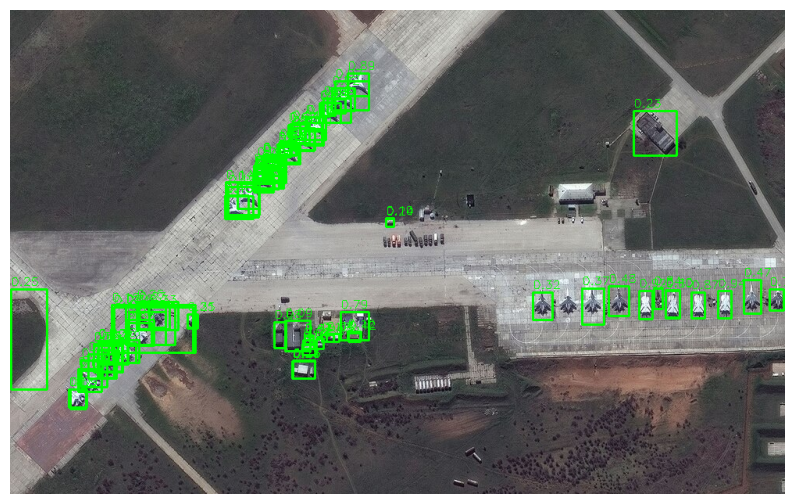

In [22]:
img_copy = img.copy()

for box, score in zip(boxes, scores):
    x1, y1, x2, y2 = box.int().numpy()
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(img_copy, f"{score:.2f}",
                (x1, y1-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0,255,0),
                1)

plt.figure(figsize=(10,10))
plt.imshow(img_copy)
plt.axis("off")

In [ ]:
COCO_CLASSES = [
    "__background__",
    "person","bicycle","car","motorcycle","airplane","bus","train","truck","boat",
    "traffic light","fire hydrant","N/A","stop sign","parking meter","bench",
    "bird","cat","dog","horse","sheep","cow","elephant","bear","zebra","giraffe",
    "N/A","backpack","umbrella","N/A","N/A","handbag","tie","suitcase","frisbee",
    "skis","snowboard","sports ball","kite","baseball bat","baseball glove",
    "skateboard","surfboard","tennis racket","bottle","N/A","wine glass","cup",
    "fork","knife","spoon","bowl","banana","apple","sandwich","orange",
    "broccoli","carrot","hot dog","pizza","donut","cake","chair","couch",
    "potted plant","bed","N/A","dining table","N/A","N/A","toilet","N/A",
    "tv","laptop","mouse","remote","keyboard","cell phone","microwave","oven",
    "toaster","sink","refrigerator","N/A","book","clock","vase","scissors",
    "teddy bear","hair drier","toothbrush"
]

In [ ]:
img_copy = img.copy()

boxes = detections[0]["boxes"]
labels = detections[0]["labels"]
scores = detections[0]["scores"]

threshold = 0.7

for box, label, score in zip(boxes, labels, scores):
    if score > threshold:
        x1, y1, x2, y2 = box.int().numpy()
        class_name = COCO_CLASSES[label]

        cv2.rectangle(img_copy, (x1,y1), (x2,y2), (255,0,0), 2)
        cv2.putText(img_copy,
                    f"{class_name} {score:.2f}",
                    (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (255,0,0),
                    1)

plt.figure(figsize=(10,10))
plt.imshow(img_copy)
plt.axis("off")

In [ ]:
count = sum(1 for label, score in zip(labels, scores) if COCO_CLASSES[label] == "airplane" and score > 0.7)
print("airplane detectadas:", count)